<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG005b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

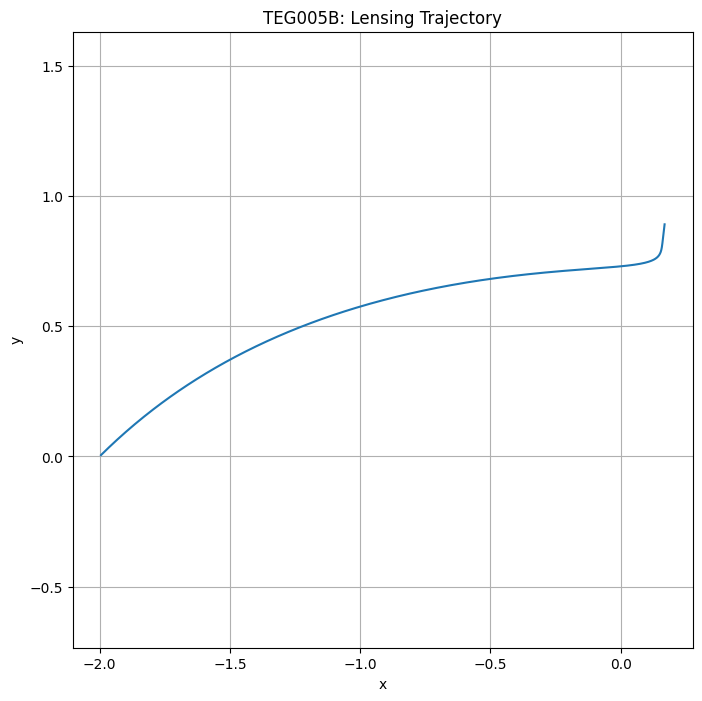

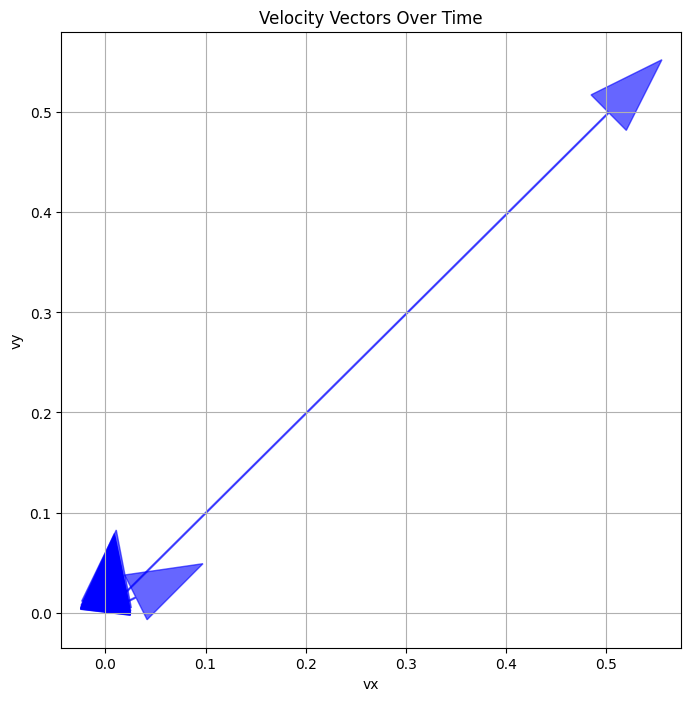

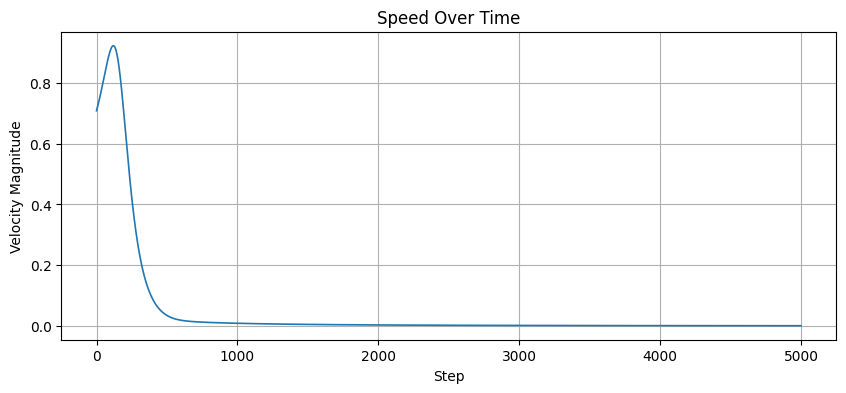

Lensing Angle (degrees): 38.34754592337248


In [1]:
# 🧬 TEG005B: Lensing & Speed Diagnostics
# Tracks trajectory bending and velocity magnitude over time
# Author: Chris & Copilot | Arc VIII: Tensorial Emergence

import numpy as np
import matplotlib.pyplot as plt

# 📐 Curvature Tensor (Anisotropic)
def curvature_tensor(x, y, sigma=1.0, epsilon=0.4):
    exp_term = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Cxx = (1 - x**2 / sigma**2) * exp_term * (1 + epsilon)
    Cyy = (1 - y**2 / sigma**2) * exp_term * (1 - epsilon)
    Cxy = (-x * y / sigma**2) * exp_term
    return np.array([[Cxx, Cxy], [Cxy, Cyy]])

# 🧲 Tensor Force
def tensor_force(x, y, vx, vy, sigma=1.0, epsilon=0.4):
    C = curvature_tensor(x, y, sigma, epsilon)
    v = np.array([vx, vy])
    f = -np.dot(C, v)
    return f[0], f[1]

# 🔁 Velocity Update
def update_velocity(vx, vy, fx, fy, dt):
    return vx + fx * dt, vy + fy * dt

# 🚀 Simulation Loop with Velocity Tracking
def simulate_lensing(x0, y0, vx0, vy0, steps=5000, dt=0.01, sigma=1.0, epsilon=0.4):
    x, y = x0, y0
    vx, vy = vx0, vy0
    trajectory = []
    velocity_vectors = []
    speed_over_time = []

    for _ in range(steps):
        fx, fy = tensor_force(x, y, vx, vy, sigma, epsilon)
        vx, vy = update_velocity(vx, vy, fx, fy, dt)
        x += vx * dt
        y += vy * dt
        trajectory.append((x, y))
        velocity_vectors.append((vx, vy))
        speed_over_time.append(np.linalg.norm([vx, vy]))

    return np.array(trajectory), np.array(velocity_vectors), np.array(speed_over_time)

# 📐 Lensing Angle Calculation
def compute_lensing_angle(initial_velocity, final_velocity):
    v0 = np.array(initial_velocity)
    vf = np.array(final_velocity)
    dot = np.dot(v0, vf)
    norm_product = np.linalg.norm(v0) * np.linalg.norm(vf)
    angle_rad = np.arccos(np.clip(dot / norm_product, -1.0, 1.0))
    angle_deg = np.degrees(angle_rad)
    return angle_deg

# 📊 Trajectory Plot
def plot_trajectory(trajectory):
    x_vals, y_vals = trajectory[:,0], trajectory[:,1]
    plt.figure(figsize=(8, 8))
    plt.plot(x_vals, y_vals, linewidth=1.5)
    plt.title("TEG005B: Lensing Trajectory")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# 📊 Velocity Vector Plot
def plot_velocity_vectors(velocity_vectors, step_interval=500):
    plt.figure(figsize=(8, 8))
    for i in range(0, len(velocity_vectors), step_interval):
        vx, vy = velocity_vectors[i]
        plt.arrow(0, 0, vx, vy, head_width=0.05, color='blue', alpha=0.6)
    plt.title("Velocity Vectors Over Time")
    plt.xlabel("vx")
    plt.ylabel("vy")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# 📉 Speed Over Time Plot
def plot_speed_over_time(speed_over_time):
    plt.figure(figsize=(10, 4))
    plt.plot(speed_over_time, linewidth=1.2)
    plt.title("Speed Over Time")
    plt.xlabel("Step")
    plt.ylabel("Velocity Magnitude")
    plt.grid(True)
    plt.show()

# 🧪 Run Lensing Test
x0, y0 = -2.0, 0.0
vx0, vy0 = 0.5, 0.5  # Diagonal launch
steps = 5000
dt = 0.01
sigma = 1.0
epsilon = 0.4

trajectory, velocity_vectors, speed_over_time = simulate_lensing(
    x0, y0, vx0, vy0, steps, dt, sigma, epsilon)

plot_trajectory(trajectory)
plot_velocity_vectors(velocity_vectors)
plot_speed_over_time(speed_over_time)

initial_velocity = velocity_vectors[0]
final_velocity = velocity_vectors[-1]
lensing_angle = compute_lensing_angle(initial_velocity, final_velocity)
print("Lensing Angle (degrees):", lensing_angle)
